# Clinical 3T MRI — B-field Mapping (G6 position)

Pipeline: Load → Clean outliers → Crop static ends → Map time→position → B vs z → dB/dz → B·dB/dz

## 1 · Load raw data

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit

# ── Config ────────────────────────────────────────────────────────────────────
DATA_FOLDER  = Path('DataCollectionFolderMRIProject')
PLOTS_DIR    = 'G6betterPlots'          # assumed to exist already
TOTAL_DIST_MM = 1252.0                # mm — full rail travel
GAUSS_TO_TESLA = 1e-4
MM_TO_M        = 1e-3
GRADIENT_CONV  = GAUSS_TO_TESLA / MM_TO_M   # G/mm → T/m  (= 0.1)
PRODUCT_CONV   = GAUSS_TO_TESLA * GRADIENT_CONV  # G²/mm → T²/m (= 1e-5)

# Instrument error: ±1% of reading + 1 G
def gauss_error(flux): return 0.01 * np.abs(flux) + 1.0

# ── Load G6 files only (N1 = forward, N2 = backward already separated) ────────
G6_FILES = {
    'G6N1': DATA_FOLDER / 'MRI3Tesla_G6N1.csv',
    'G6N2': DATA_FOLDER / 'MRI3Tesla_G6N2.csv',
}

raw = {}
for key, fpath in G6_FILES.items():
    df = pd.read_csv(fpath)[['time','flux']]
    raw[key] = df
    print(f"  {key}: {len(df):,} rows   time {df['time'].iloc[0]:.2f}→{df['time'].iloc[-1]:.2f} s")

print("\nLoaded.")


  G6N1: 120 rows   time 0.25→30.00 s
  G6N2: 120 rows   time 0.25→30.00 s

Loaded.


## 2 · B vs Time (raw — one subplot per run)

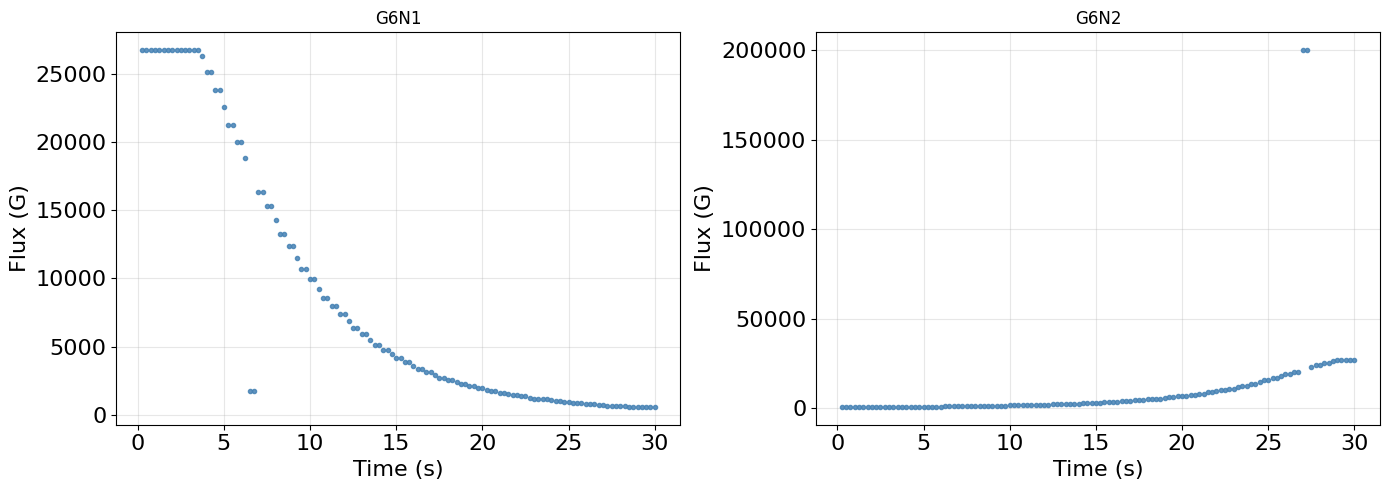

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (key, df) in zip(axes, raw.items()):
    ax.plot(df['time'], df['flux'], color='steelblue', marker='o', markersize=3, linestyle='none', alpha=0.85)
    ax.set_title(key)
    ax.tick_params(axis='both', labelsize=16)
    ax.set_xlabel('Time (s)',fontsize = 16)
    ax.set_ylabel('Flux (G)',fontsize = 16)
    ax.grid(True, alpha=0.3)

#fig.suptitle('Raw B vs Time — G6', fontsize=13)
plt.tight_layout()
#plt.savefig(f'{PLOTS_DIR}/G6_BvsTime_raw.png', dpi=300, bbox_inches='tight')
plt.show()


## 3 · Remove gaussmeter artefacts

Systematic spikes from the gaussmeter sampling are removed with a **3-σ residual cut**
against an exponential fit. Only a small number of points are expected to be removed.


In [3]:
def remove_outliers(df, sigma_cut=3.0):
    """Fit exponential baseline, remove points whose residual > sigma_cut * std."""
    def exp_func(t, a, b, c): return a * np.exp(-b * t) + c
    df = df.copy().reset_index(drop=True)
    try:
        p0 = [df['flux'].max(), 0.1, df['flux'].min()]
        popt, _ = curve_fit(exp_func, df['time'], df['flux'], p0=p0, maxfev=10000)
        residuals = df['flux'] - exp_func(df['time'], *popt)
        mask = np.abs(residuals) < sigma_cut * residuals.std()
        removed = (~mask).sum()
        print(f"  Removed {removed} outlier(s) ({100*removed/len(df):.1f}%)")
        return df[mask].reset_index(drop=True)
    except Exception as e:
        print(f"  Fit failed ({e}) — keeping all points")
        return df

clean = {}
for key, df in raw.items():
    print(key)
    clean[key] = remove_outliers(df)


G6N1
  Removed 2 outlier(s) (1.7%)
G6N2
  Removed 2 outlier(s) (1.7%)


## 4 · Crop static ends

The probe was left running before and after movement. Crop leading/trailing segments
where the flux barely changes (consecutive difference ≤ tolerance).


In [4]:
def crop_static_ends(df, tolerance=1.0):
    """Remove leading and trailing near-constant flux plateaus."""
    flux = df['flux'].values
    n = len(flux)

    # find first changing point from start
    start = 0
    while start < n - 1 and abs(flux[start] - flux[start+1]) <= tolerance:
        start += 1

    # find last changing point from end
    end = n - 1
    while end > 0 and abs(flux[end] - flux[end-1]) <= tolerance:
        end -= 1

    if start > end:
        start, end = 0, n - 1

    df_out = df.iloc[start:end+1].reset_index(drop=True)
    print(f"  Cropped {start} pts from start, {n-end-1} from end  →  {len(df_out)} rows remain  "
          f"(time {df_out['time'].iloc[0]:.2f}→{df_out['time'].iloc[-1]:.2f} s)")
    return df_out

cropped = {}
for key, df in clean.items():
    print(key)
    cropped[key] = crop_static_ends(df, tolerance=1.0)


G6N1
  Cropped 13 pts from start, 4 from end  →  101 rows remain  (time 3.50→29.00 s)
G6N2
  Cropped 13 pts from start, 2 from end  →  103 rows remain  (time 3.50→29.50 s)


## 5 · Map time → position

Assume **constant average velocity** over the cropped window.
- **G6N1** (N1): forward pass → position increases 0 → 1252 mm
- **G6N2** (N2): backward pass → position decreases 1252 → 0 mm (reversed)


In [5]:
def map_position(df, key, total_dist=TOTAL_DIST_MM):
    df = df.copy()
    t0, t1 = df['time'].iloc[0], df['time'].iloc[-1]
    dt = t1 - t0
    v  = total_dist / dt
    df['position'] = (df['time'] - t0) * v          # 0 → total_dist

    # N2/N4 runs go in reverse
    if 'N2' in key.upper() or 'N4' in key.upper():
        df['position'] = total_dist - df['position']
        direction = 'forward'
    else:
        direction = 'backwards'

    print(f"  {key}: v = {v:.2f} mm/s  |  direction = {direction}")
    return df

mapped = {}
for key, df in cropped.items():
    print(key)
    mapped[key] = map_position(df, key)


G6N1
  G6N1: v = 49.10 mm/s  |  direction = backwards
G6N2
  G6N2: v = 48.15 mm/s  |  direction = forward


## 6 · B vs Position — Forward and Backward (G6 only)

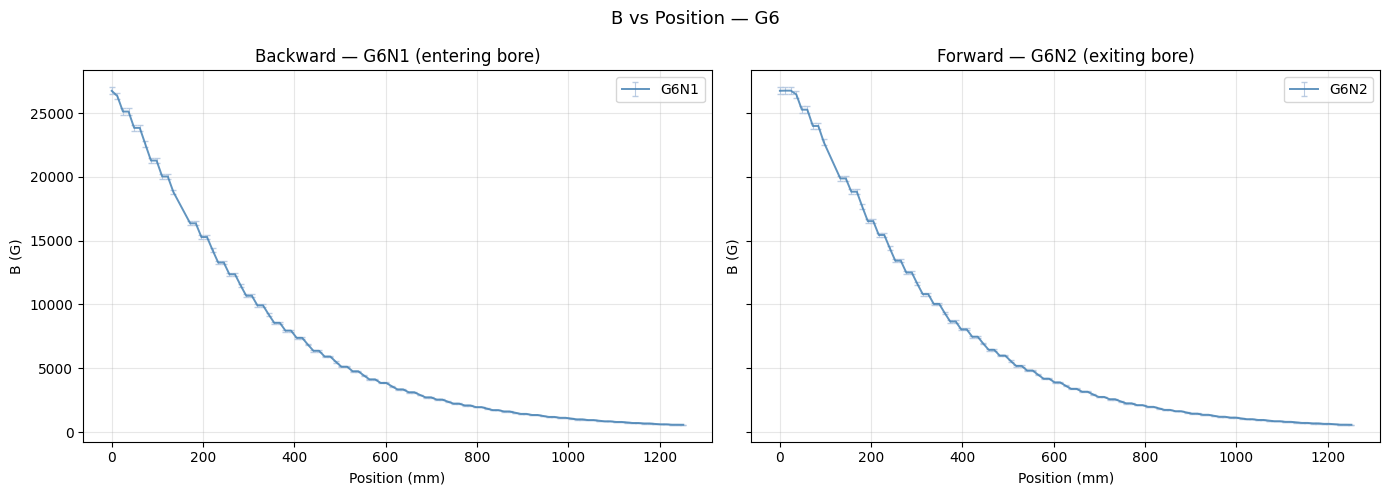

In [6]:
# N1 = forward (entering bore), N2 = backward (exiting bore)
fwd_key, bwd_key = 'G6N1', 'G6N2'

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
titles = ['Backward — G6N1 (entering bore)', 'Forward — G6N2 (exiting bore)']

for ax, key, title in zip(axes, [fwd_key, bwd_key], titles):
    df = mapped[key]
    yerr = gauss_error(df['flux'].values)
    ax.errorbar(df['position'], df['flux'], yerr=yerr,
                fmt='-', color='steelblue', ecolor='lightsteelblue',
                lw=1.4, elinewidth=0.8, capsize=2, alpha=0.85, label=key)
    ax.set_xlabel('Position (mm)')
    ax.set_ylabel('B (G)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle('B vs Position — G6', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/G6_BvsPosition.png', dpi=300, bbox_inches='tight')
plt.show()


## 7 · Central-difference gradient helper

In [7]:
def central_diff(pos_mm, flux_G, bin_size_mm=12.0):
    """
    1) Bin flux into bins of bin_size_mm (average B per bin).
       bin_size_mm ≈ 12 mm matches the natural spacing of the clinical data.
    2) Apply 2nd-order central differences on the binned data.
    3) Clip top 2% outliers.
    Returns (z_binned, dBdz) both in G/mm.
    """
    pos = pos_mm.astype(float)
    flux = flux_G.astype(float)

    bins = np.arange(np.floor(pos.min()), np.ceil(pos.max()) + bin_size_mm, bin_size_mm)
    idx  = np.digitize(pos, bins)
    z_b, B_b = [], []
    for i in range(1, len(bins)):
        m = idx == i
        if m.sum() > 0:
            z_b.append(pos[m].mean())
            B_b.append(flux[m].mean())

    z_b = np.array(z_b)
    B_b = np.array(B_b)
    n   = len(z_b)
    dBdz = np.full(n, np.nan)

    # interior: central difference
    dz_c = z_b[2:] - z_b[:-2]
    dz_c[dz_c == 0] = np.nan
    dBdz[1:-1] = (B_b[2:] - B_b[:-2]) / dz_c

    # boundaries: one-sided
    dz_l = z_b[1]  - z_b[0]
    dz_r = z_b[-1] - z_b[-2]
    if dz_l != 0: dBdz[0]  = (B_b[1]  - B_b[0])  / dz_l
    if dz_r != 0: dBdz[-1] = (B_b[-1] - B_b[-2]) / dz_r

    # clip top 2 % outliers
    finite = dBdz[np.isfinite(dBdz)]
    if len(finite):
        hi = np.percentile(np.abs(finite), 98)
        dBdz[np.abs(dBdz) > hi] = np.nan

    return z_b, dBdz, B_b

print("central_diff() ready  (bin_size_mm=12 matches clinical data spacing)")


central_diff() ready  (bin_size_mm=12 matches clinical data spacing)


## 8 · dB/dz vs Position — Forward and Backward

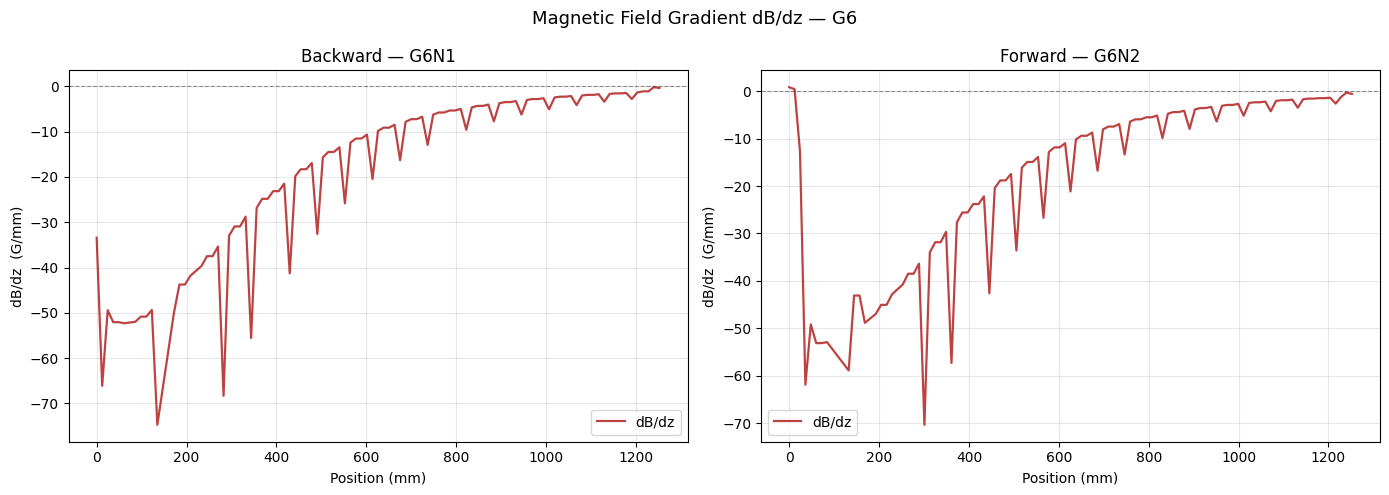

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
titles = ['Backward — G6N1', 'Forward — G6N2']

for ax, key, title in zip(axes, [fwd_key, bwd_key], titles):
    df = mapped[key]
    z_b, dBdz, _ = central_diff(df['position'].values, df['flux'].values)

    ok = np.isfinite(dBdz)
    ax.plot(z_b[ok], dBdz[ok], color='firebrick', lw=1.6, alpha=0.85, label='dB/dz')
    ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
    ax.set_xlabel('Position (mm)')
    ax.set_ylabel('dB/dz  (G/mm)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle('Magnetic Field Gradient dB/dz — G6', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/G6_gradB.png', dpi=300, bbox_inches='tight')
plt.show()


## 9 · B · dB/dz vs Position — Forward and Backward

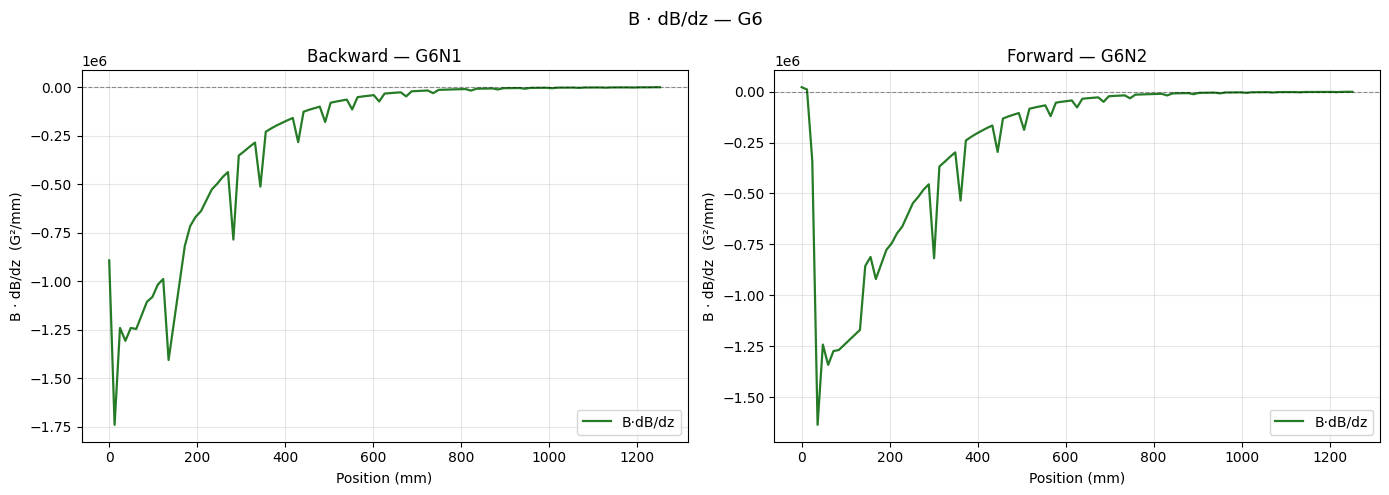

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
titles = ['Backward — G6N1', 'Forward — G6N2']

for ax, key, title in zip(axes, [fwd_key, bwd_key], titles):
    df = mapped[key]
    z_b, dBdz, B_b = central_diff(df['position'].values, df['flux'].values)
    BgradB = B_b * dBdz

    ok = np.isfinite(BgradB)
    ax.plot(z_b[ok], BgradB[ok], color='darkgreen', lw=1.6, alpha=0.85, label='B·dB/dz')
    ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
    ax.set_xlabel('Position (mm)')
    ax.set_ylabel('B · dB/dz  (G²/mm)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle('B · dB/dz — G6', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/G6_BgradB.png', dpi=300, bbox_inches='tight')
plt.show()


## 10 · Summary table in SI units (T, T/m, T²/m)

In [10]:
print(f"{'Run':8} {'Pass':10} {'pos @ max |B·∇B| (mm)':25} {'B (T)':10} {'dB/dz (T/m)':14} {'B·dB/dz (T²/m)':16}")
print('─'*85)

for key, title in [(fwd_key,'Forward'), (bwd_key,'Backward')]:
    df = mapped[key]
    z_b, dBdz, B_b = central_diff(df['position'].values, df['flux'].values)
    BgradB = B_b * dBdz

    ok = np.isfinite(BgradB)
    if ok.sum() == 0:
        print(f"{key:8} {title:10}  — no valid points")
        continue

    idx = np.nanargmax(np.abs(BgradB[ok]))
    z_sel    = z_b[ok][idx]
    B_sel    = B_b[ok][idx]
    grad_sel = dBdz[ok][idx]
    Bg_sel   = BgradB[ok][idx]

    print(f"{key:8} {title:10}  {z_sel:>10.1f} mm             "          f"{B_sel*GAUSS_TO_TESLA:>8.4f} T   "          f"{grad_sel*GRADIENT_CONV:>10.4f} T/m   "          f"{Bg_sel*PRODUCT_CONV:>12.4f} T²/m")


Run      Pass       pos @ max |B·∇B| (mm)     B (T)      dB/dz (T/m)    B·dB/dz (T²/m)  
─────────────────────────────────────────────────────────────────────────────────────
G6N1     Forward           12.3 mm               2.6327 T      -6.6113 T/m       -17.4055 T²/m
G6N2     Backward          36.1 mm               2.6447 T      -6.1885 T/m       -16.3667 T²/m


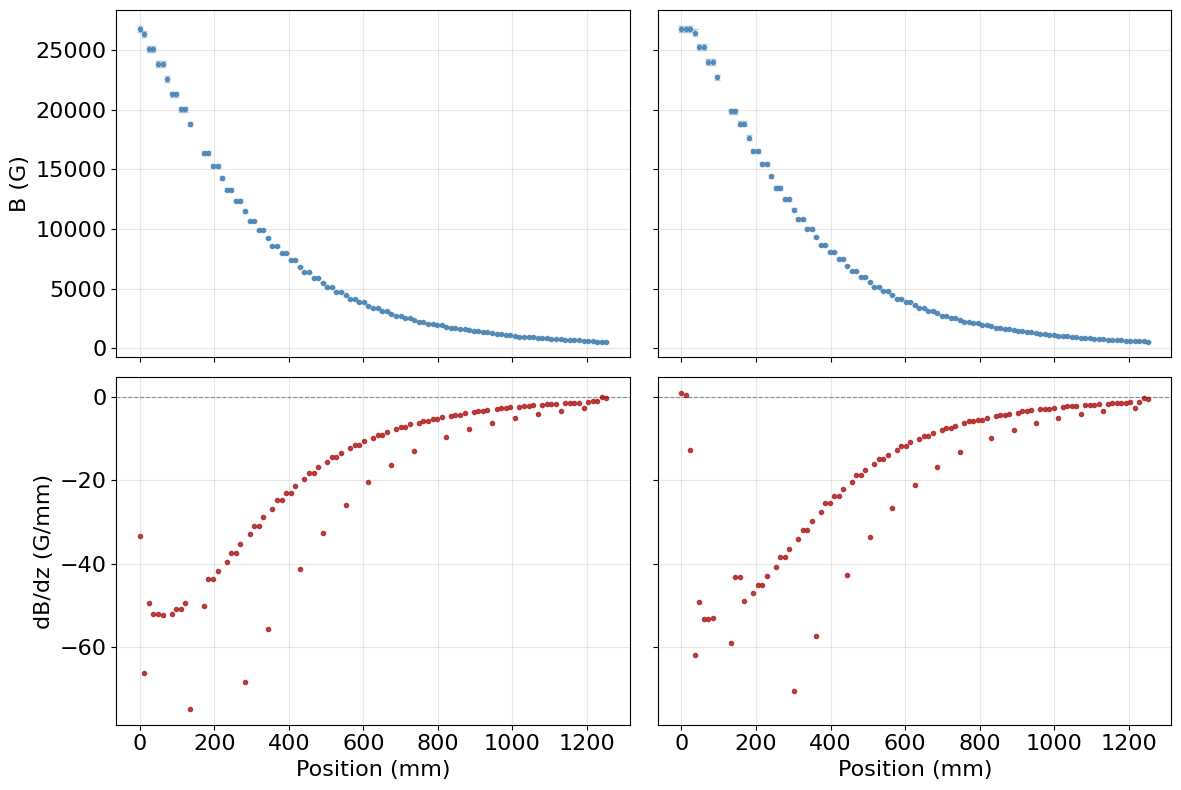

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey='row')

# =========================
# TOP ROW — STEP 6 (B vs z)
# =========================

for col, key in enumerate([fwd_key, bwd_key]):
    df = mapped[key]
    yerr = gauss_error(df['flux'].values)

    axs[0, col].errorbar(
        df['position'], df['flux'], yerr=yerr,
        color='steelblue', ecolor='lightsteelblue',
        marker='o', markersize=3, linestyle='none', capsize=2, alpha=0.85
    )

# =========================
# BOTTOM ROW — STEP 8 (dB/dz)
# =========================

for col, key in enumerate([fwd_key, bwd_key]):
    df = mapped[key]
    z_b, dBdz, _ = central_diff(df['position'].values, df['flux'].values)

    ok = np.isfinite(dBdz)

    axs[1, col].plot(
        z_b[ok], dBdz[ok],
        color='firebrick', marker='o', markersize=3, linestyle='none', alpha=0.85
    )
    axs[1, col].axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)

# =========================
# FORMATTING
# =========================

for ax in axs.flat:
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=16)

axs[0, 0].set_ylabel('B (G)', fontsize=16)
axs[1, 0].set_ylabel('dB/dz (G/mm)', fontsize=16)

# Only bottom row has x-axis labels
#for ax in axs[0, :]:
 #   ax.set_xticklabels([])

for ax in axs[1, :]:
    ax.set_xlabel('Position (mm)', fontsize=16)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/G6_posNBgradB.png', dpi=300, bbox_inches='tight')
plt.show()